# 04 -- Statistical Analysis

**Project:** Uber Data Visualization and Analysis  
**Input:** `data/processed/uber_trips_cleaned.csv`  

Covers correlation analysis, hypothesis testing, distribution analysis, outlier detection, and trip segmentation.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, ttest_ind, f_oneway, chi2_contingency

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (11, 5)

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == 'notebooks'
    else Path.cwd().resolve()
)
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'uber_trips_cleaned.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['pickup_time', 'drop_time'])

print(f'Loaded {len(df):,} rows')

Loaded 49,997 rows


## 1. Correlation Analysis

**Question:** How strongly are fare, distance, duration, and fare_per_km related to each other?

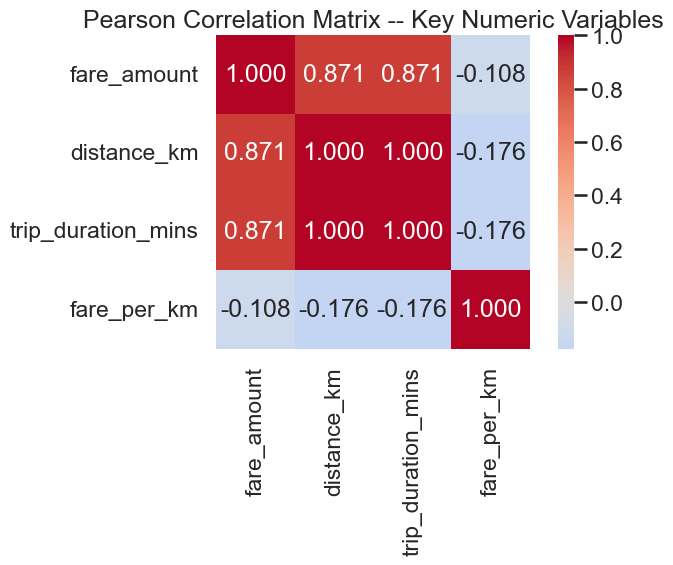


Correlation matrix:
                    fare_amount  distance_km  trip_duration_mins  fare_per_km
fare_amount              1.0000       0.8706              0.8706      -0.1076
distance_km              0.8706       1.0000              1.0000      -0.1761
trip_duration_mins       0.8706       1.0000              1.0000      -0.1761
fare_per_km             -0.1076      -0.1761             -0.1761       1.0000


In [2]:
numeric_cols = ['fare_amount', 'distance_km', 'trip_duration_mins', 'fare_per_km']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, ax=ax)
ax.set_title('Pearson Correlation Matrix -- Key Numeric Variables')
plt.tight_layout()
plt.show()

print('\nCorrelation matrix:')
print(corr_matrix.round(4))

**Interpretation:** A high positive correlation between fare and distance confirms that pricing is distance-driven. Fare per km shows how pricing efficiency varies independently of trip length.

## 2. Distribution Analysis -- Skewness and Kurtosis

**Question:** Are fare, distance, and duration normally distributed or skewed?

In [3]:
dist_cols = ['fare_amount', 'distance_km', 'trip_duration_mins']
print(f'{'Column':<25} {'Skewness':>12} {'Kurtosis':>12} {'Interpretation'}')
print('-' * 70)
for col in dist_cols:
    skew = df[col].skew()
    kurt = df[col].kurt()
    direction = 'Right-skewed' if skew > 0.5 else ('Left-skewed' if skew < -0.5 else 'Approx. symmetric')
    print(f'{col:<25} {skew:>12.4f} {kurt:>12.4f}  {direction}')

Column                        Skewness     Kurtosis Interpretation
----------------------------------------------------------------------
fare_amount                     0.4817       0.2720  Approx. symmetric
distance_km                     0.1080      -0.1868  Approx. symmetric
trip_duration_mins              0.1080      -0.1868  Approx. symmetric


## 3. Normality Test (Shapiro-Wilk)

Applied on a random sample of 1,000 records (Shapiro-Wilk is designed for small samples).

In [4]:
sample_size = 1000
print(f'Shapiro-Wilk Normality Test (sample n={sample_size})')
print(f'H0: Data is normally distributed')
print(f'Alpha: 0.05\n')

for col in dist_cols:
    sample = df[col].dropna().sample(sample_size, random_state=42)
    stat, p = shapiro(sample)
    result = 'Reject H0 (not normal)' if p < 0.05 else 'Fail to reject H0 (normal)'
    print(f'  {col:<25}: stat={stat:.4f}, p={p:.6f}  --> {result}')

Shapiro-Wilk Normality Test (sample n=1000)
H0: Data is normally distributed
Alpha: 0.05

  fare_amount              : stat=0.9826, p=0.000000  --> Reject H0 (not normal)
  distance_km              : stat=0.9955, p=0.005236  --> Reject H0 (not normal)
  trip_duration_mins       : stat=0.9955, p=0.005281  --> Reject H0 (not normal)


## 4. Hypothesis Test 1 -- Weekday vs Weekend Fares

**H0:** Mean fare on weekdays = mean fare on weekends  
**H1:** Mean fare differs between weekdays and weekends  
**Test:** Two-sample independent t-test (Welch's), alpha = 0.05

In [5]:
weekday_fares = df[df['is_weekend'] == False]['fare_amount']
weekend_fares = df[df['is_weekend'] == True]['fare_amount']

t_stat, p_val = ttest_ind(weekday_fares, weekend_fares, equal_var=False)

print('Weekday vs Weekend Fare -- Welch t-test')
print(f'  Weekday mean fare : {weekday_fares.mean():.4f}')
print(f'  Weekend mean fare : {weekend_fares.mean():.4f}')
print(f'  t-statistic       : {t_stat:.4f}')
print(f'  p-value           : {p_val:.6f}')
print(f'  Decision          : {"Reject H0 -- significant difference" if p_val < 0.05 else "Fail to reject H0 -- no significant difference"}')

Weekday vs Weekend Fare -- Welch t-test
  Weekday mean fare : 16.0030
  Weekend mean fare : 15.9101
  t-statistic       : 1.4887
  p-value           : 0.136588
  Decision          : Fail to reject H0 -- no significant difference


## 5. Hypothesis Test 2 -- Average Fare Across Cities (One-Way ANOVA)

**H0:** Mean fare is equal across all 6 cities  
**H1:** At least one city has a significantly different mean fare  
**Test:** One-Way ANOVA, alpha = 0.05

In [6]:
city_groups = [grp['fare_amount'].values for _, grp in df.groupby('city')]
f_stat, p_val_anova = f_oneway(*city_groups)

print('One-Way ANOVA -- Fare Across Cities')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_val_anova:.6f}')
print(f'  Decision    : {"Reject H0 -- significant fare differences between cities" if p_val_anova < 0.05 else "Fail to reject H0 -- no significant fare differences"}')

print('\nCity mean fares:')
print(df.groupby('city')['fare_amount'].mean().sort_values(ascending=False).round(4))

One-Way ANOVA -- Fare Across Cities
  F-statistic : 2.8379
  p-value     : 0.014458
  Decision    : Reject H0 -- significant fare differences between cities

City mean fares:
city
Seattle          16.0621
Boston           16.0521
New York         16.0485
San Francisco    16.0232
Chicago          15.9024
Los Angeles      15.7734
Name: fare_amount, dtype: float64


## 6. Hypothesis Test 3 -- Trip Status Independence from Payment Method

**H0:** Trip status (Completed/Cancelled/No-Show) is independent of payment method  
**H1:** Trip status and payment method are associated  
**Test:** Chi-squared test of independence, alpha = 0.05

In [7]:
contingency = pd.crosstab(df['status'], df['payment_method'])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)

print('Chi-Squared Test -- Trip Status vs Payment Method')
print(f'  Chi2 statistic : {chi2:.4f}')
print(f'  Degrees of freedom: {dof}')
print(f'  p-value        : {p_chi2:.6f}')
print(f'  Decision       : {"Reject H0 -- status and payment method are associated" if p_chi2 < 0.05 else "Fail to reject H0 -- no significant association"}')

print('\nContingency table:')
print(contingency)

Chi-Squared Test -- Trip Status vs Payment Method
  Chi2 statistic : 9.3825
  Degrees of freedom: 6
  p-value        : 0.153180
  Decision       : Fail to reject H0 -- no significant association

Contingency table:
payment_method   Card   Cash    Upi  Wallet
status                                     
Cancelled        1196   1230   1307    1251
Completed       10674  10568  10652   10644
No-Show           661    615    589     610


## 7. Hypothesis Test 4 -- Morning vs Evening Trip Duration

**H0:** Mean trip duration in the morning (6-12) = mean trip duration in the evening (17-21)  
**H1:** Trip duration differs between morning and evening  
**Test:** Two-sample t-test, alpha = 0.05

In [8]:
morning = df[df['time_of_day'] == 'Morning (6-12)']['trip_duration_mins']
evening = df[df['time_of_day'] == 'Evening (17-21)']['trip_duration_mins']

t_stat2, p_val2 = ttest_ind(morning, evening, equal_var=False)

print('Morning vs Evening Trip Duration -- Welch t-test')
print(f'  Morning mean duration : {morning.mean():.4f} mins')
print(f'  Evening mean duration : {evening.mean():.4f} mins')
print(f'  t-statistic           : {t_stat2:.4f}')
print(f'  p-value               : {p_val2:.6f}')
print(f'  Decision              : {"Reject H0 -- significant difference" if p_val2 < 0.05 else "Fail to reject H0 -- no significant difference"}')

Morning vs Evening Trip Duration -- Welch t-test
  Morning mean duration : 21.0564 mins
  Evening mean duration : 21.1242 mins
  t-statistic           : -0.5398
  p-value               : 0.589333
  Decision              : Fail to reject H0 -- no significant difference


## 8. Outlier Detection -- IQR Method

In [9]:
def iqr_outlier_summary(series: pd.Series, label: str) -> None:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    pct = n_outliers / len(series) * 100
    mean_all = series.mean()
    mean_clean = series[(series >= lower) & (series <= upper)].mean()
    print(f'\n{label}')
    print(f'  IQR bounds  : [{lower:.4f}, {upper:.4f}]')
    print(f'  Outliers    : {n_outliers} ({pct:.2f}%)')
    print(f'  Mean (all)  : {mean_all:.4f}')
    print(f'  Mean (clean): {mean_clean:.4f}')

for col in ['fare_amount', 'distance_km', 'trip_duration_mins']:
    iqr_outlier_summary(df[col], col)


fare_amount
  IQR bounds  : [-1.0900, 32.5100]
  Outliers    : 495 (0.99%)
  Mean (all)  : 15.9770
  Mean (clean): 15.7810

distance_km
  IQR bounds  : [-1.0500, 15.0300]
  Outliers    : 208 (0.42%)
  Mean (all)  : 7.0085
  Mean (clean): 6.9709

trip_duration_mins
  IQR bounds  : [-3.1750, 45.1050]
  Outliers    : 208 (0.42%)
  Mean (all)  : 21.0255
  Mean (clean): 20.9127


## 9. Trip Segmentation by Fare Tier

Trips are segmented into Budget, Standard, and Premium tiers based on fare distribution quartiles.

In [10]:
fare_q33 = df['fare_amount'].quantile(0.33)
fare_q66 = df['fare_amount'].quantile(0.66)

def assign_tier(fare: float) -> str:
    if fare <= fare_q33:
        return 'Budget'
    elif fare <= fare_q66:
        return 'Standard'
    return 'Premium'

df['fare_tier'] = df['fare_amount'].apply(assign_tier)

print(f'Fare tier thresholds:')
print(f'  Budget   : <= {fare_q33:.2f}')
print(f'  Standard : {fare_q33:.2f} to {fare_q66:.2f}')
print(f'  Premium  : > {fare_q66:.2f}')

tier_summary = df.groupby('fare_tier').agg(
    Trip_Count=('trip_id', 'count'),
    Avg_Fare=('fare_amount', 'mean'),
    Avg_Distance=('distance_km', 'mean'),
    Avg_Duration=('trip_duration_mins', 'mean'),
    Completion_Rate=('status', lambda x: (x == 'Completed').mean() * 100),
).round(2)

print('\nFare Tier Segment Summary:')
print(tier_summary)

Fare tier thresholds:
  Budget   : <= 12.87
  Standard : 12.87 to 18.09
  Premium  : > 18.09

Fare Tier Segment Summary:
           Trip_Count  Avg_Fare  Avg_Distance  Avg_Duration  Completion_Rate
fare_tier                                                                   
Budget          16528      9.39          4.09         12.28            85.27
Premium         16989     22.93          9.74         29.21            84.96
Standard        16480     15.41          7.12         21.36            85.02


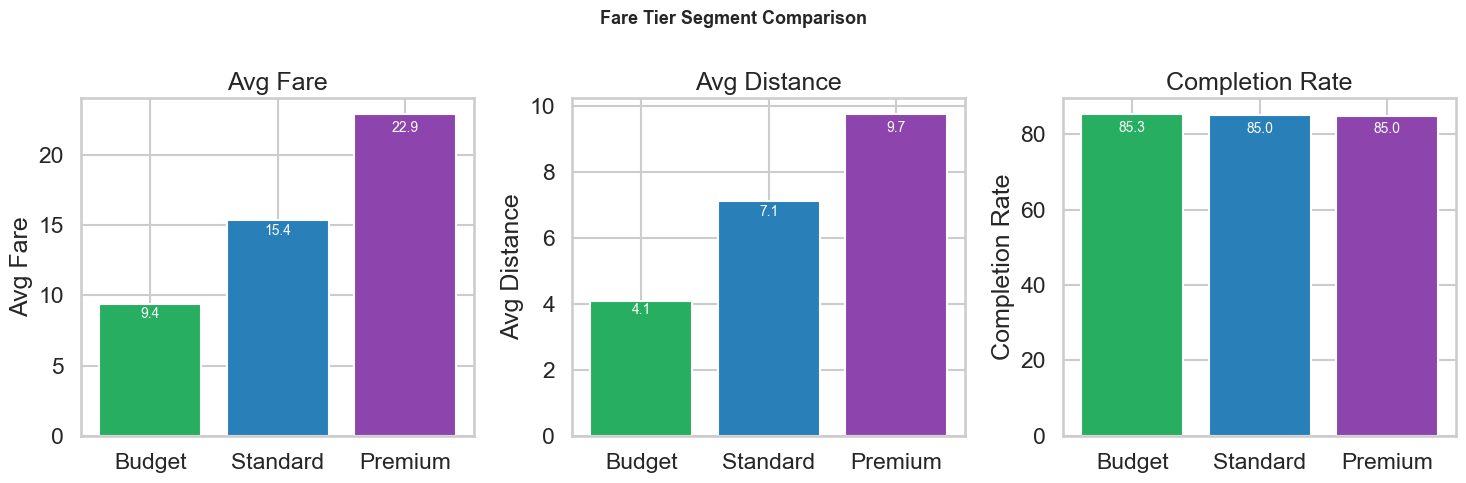

In [11]:
tier_order = ['Budget', 'Standard', 'Premium']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['Avg_Fare', 'Avg_Distance', 'Completion_Rate']):
    vals = tier_summary.reindex(tier_order)[metric]
    ax.bar(tier_order, vals, color=['#27ae60', '#2980b9', '#8e44ad'])
    ax.set_title(metric.replace('_', ' '))
    ax.set_ylabel(metric.replace('_', ' '))
    for i, v in enumerate(vals):
        ax.text(i, v * 0.98, f'{v:.1f}', ha='center', va='top', fontsize=10, color='white')

plt.suptitle('Fare Tier Segment Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

**Next Step:** `05_final_load_prep.ipynb` -- Final Dataset Preparation for Tableau